# <b>Prevendo taxas de câmbio à vista com ARIMA.

- # Carregar bibliotecas.

### Execute o código a seguir para instalar as bibliotecas necessárias ao iniciar as etapas de previsão:

In [124]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pylab as plt
%matplotlib inline
from matplotlib.pylab import rcParams
rcParams['figure.figsize'] = 15, 6
import requests, pandas as pd, numpy as np
from pandas import DataFrame
from io import StringIO
import time, json
from datetime import date
import statsmodels
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.tsa.arima_model import ARIMA
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_squared_error

# Carregar e visualizar os dados da série temporal.

In [127]:
df_fx_data = pd.read_csv('D:/Github/portfolio/ciencia-de-dados/exchange-rate-forecast/boe-xudlerd.csv')

In [128]:
import sys

In [129]:
df_fx_data['Date'] = pd.to_datetime(df_fx_data['Date'], format = '%Y-%m-%d')
indexed_df = df_fx_data.set_index('Date')

In [130]:
df_fx_data.head()

,Date,Value
0,2023-01-23,0.9206
1,2023-01-20,0.9233
2,2023-01-19,0.9268
3,2023-01-18,0.9230
4,2023-01-17,0.9258


# Mostrar as primeiras 5 linhas:

In [132]:
ts_euro = indexed_df['Value']
ts_euro.head(5)

Date
2023-01-23    0.9206
2023-01-20    0.9233
2023-01-19    0.9268
2023-01-18    0.9230
2023-01-17    0.9258
Name: Value, dtype: float64

# Visualize os dados brutos.

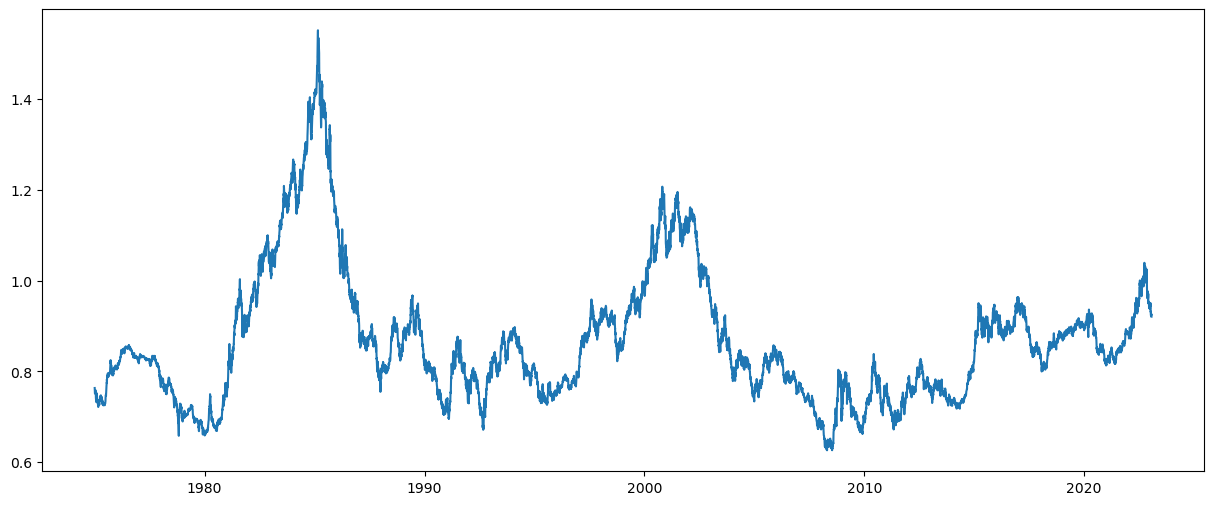

In [134]:
plt.plot(ts_euro.index.to_pydatetime(), ts_euro.values)

# Reamostrar os dados.

In [136]:
ts_euro_week = ts_euro.resample('W').mean()

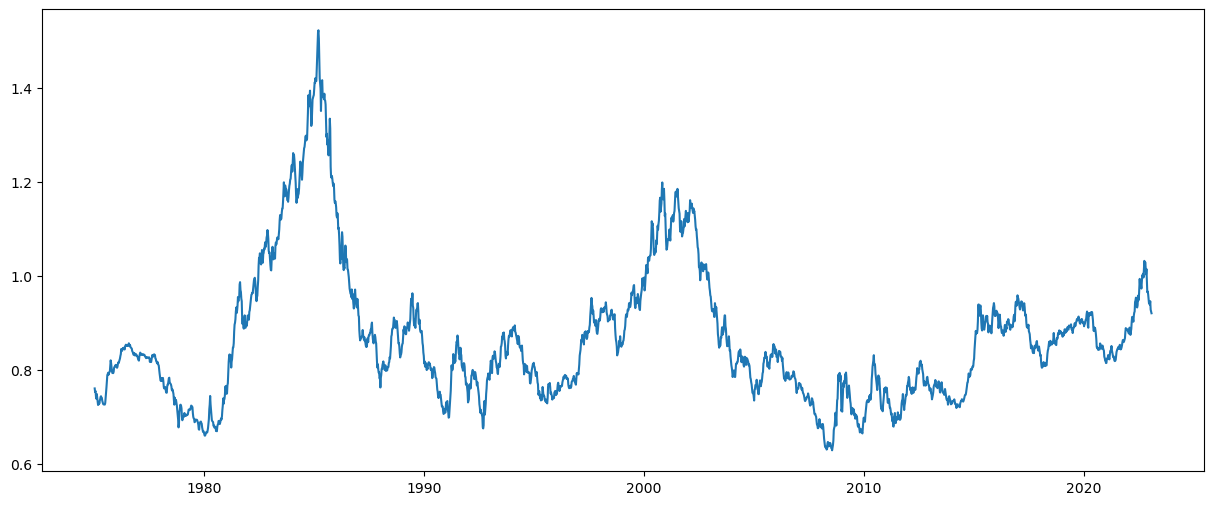

In [137]:
plt.plot(ts_euro_week.index.to_pydatetime(), ts_euro_week.values)

# Verifique a estacionaridade.

### Calcule as variâncias móveis, plote os resultados e aplique o teste Dickey-Fuller na série temporal:

In [140]:
def check_stationarity(timeseries):
    
    #Determing rolling statistics
    rolling_mean = timeseries.rolling(window=52,center=False).mean() 
    rolling_std = timeseries.rolling(window=52,center=False).std()

    #Plot rolling statistics:
    original = plt.plot(timeseries.index.to_pydatetime(), timeseries.values, color='blue',label='Original')
    mean = plt.plot(rolling_mean.index.to_pydatetime(), rolling_mean.values, color='red', label='Rolling Mean')
    std = plt.plot(rolling_std.index.to_pydatetime(), rolling_std.values, color='black', label = 'Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show(block=False)
    
    #Perform Dickey-Fuller test:
    print ('Results of Dickey-Fuller Test:')
    dickey_fuller_test = adfuller(timeseries, autolag='AIC')
    dfresults = pd.Series(dickey_fuller_test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in dickey_fuller_test[4].items():
        dfresults['Critical Value (%s)'%key] = value
    print (dfresults)

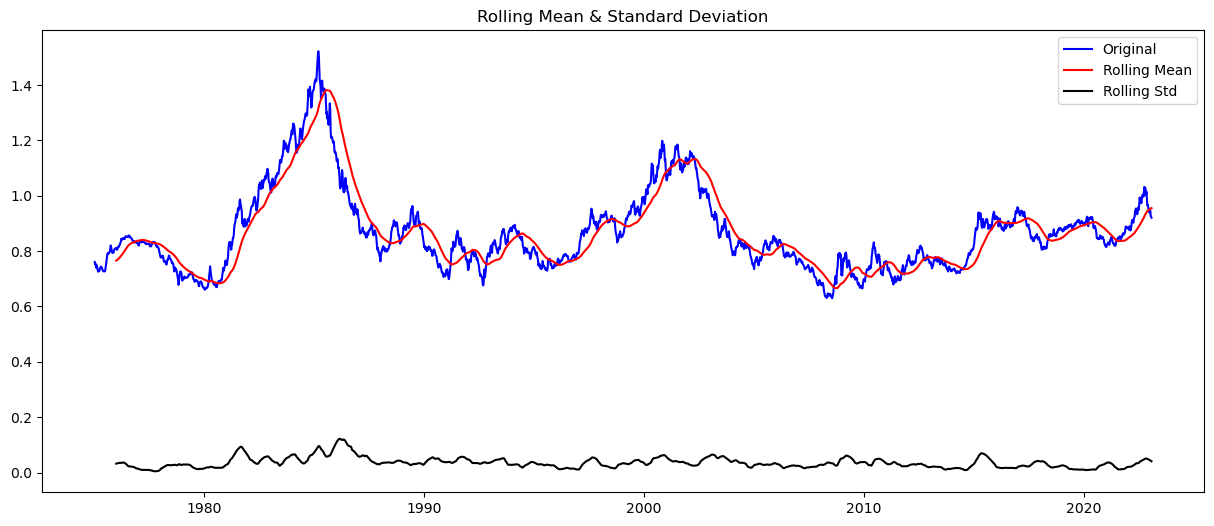

Results of Dickey-Fuller Test:
Test Statistic                   -2.211283
p-value                           0.202176
#Lags Used                        2.000000
Number of Observations Used    2506.000000
Critical Value (1%)              -3.432962
Critical Value (5%)              -2.862694
Critical Value (10%)             -2.567384
dtype: float64


In [141]:
check_stationarity(ts_euro_week)

# Estacionar a série temporal.

### Aplicar uma transformação de log não linear.

In [144]:
ts_euro_week_log = np.log(ts_euro_week)

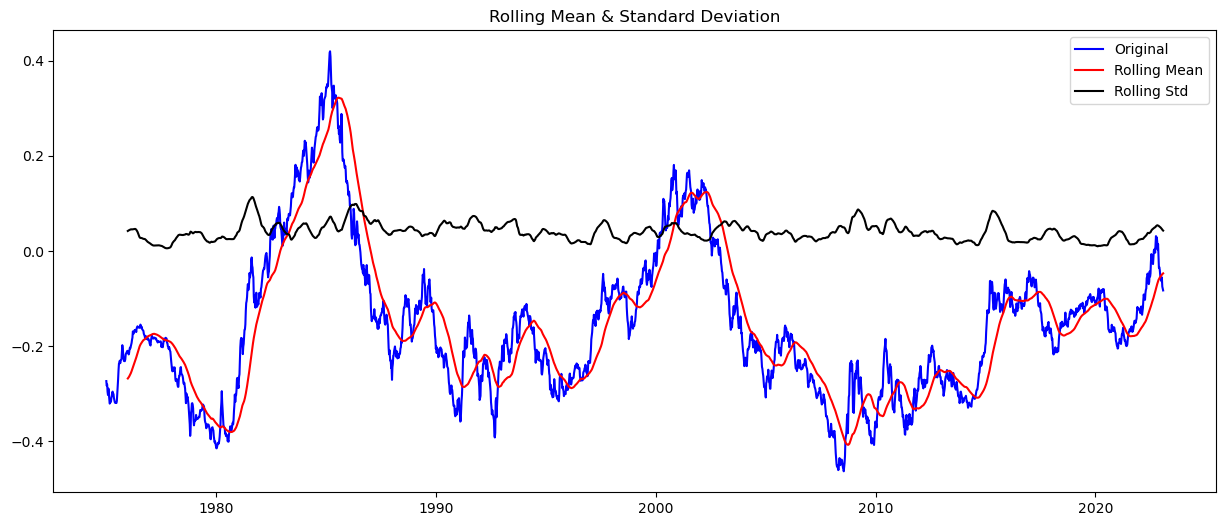

Results of Dickey-Fuller Test:
Test Statistic                   -2.409256
p-value                           0.139141
#Lags Used                        3.000000
Number of Observations Used    2505.000000
Critical Value (1%)              -3.432963
Critical Value (5%)              -2.862694
Critical Value (10%)             -2.567385
dtype: float64


In [145]:
check_stationarity(ts_euro_week_log)

# Remova tendência e sazonalidade com decomposição.

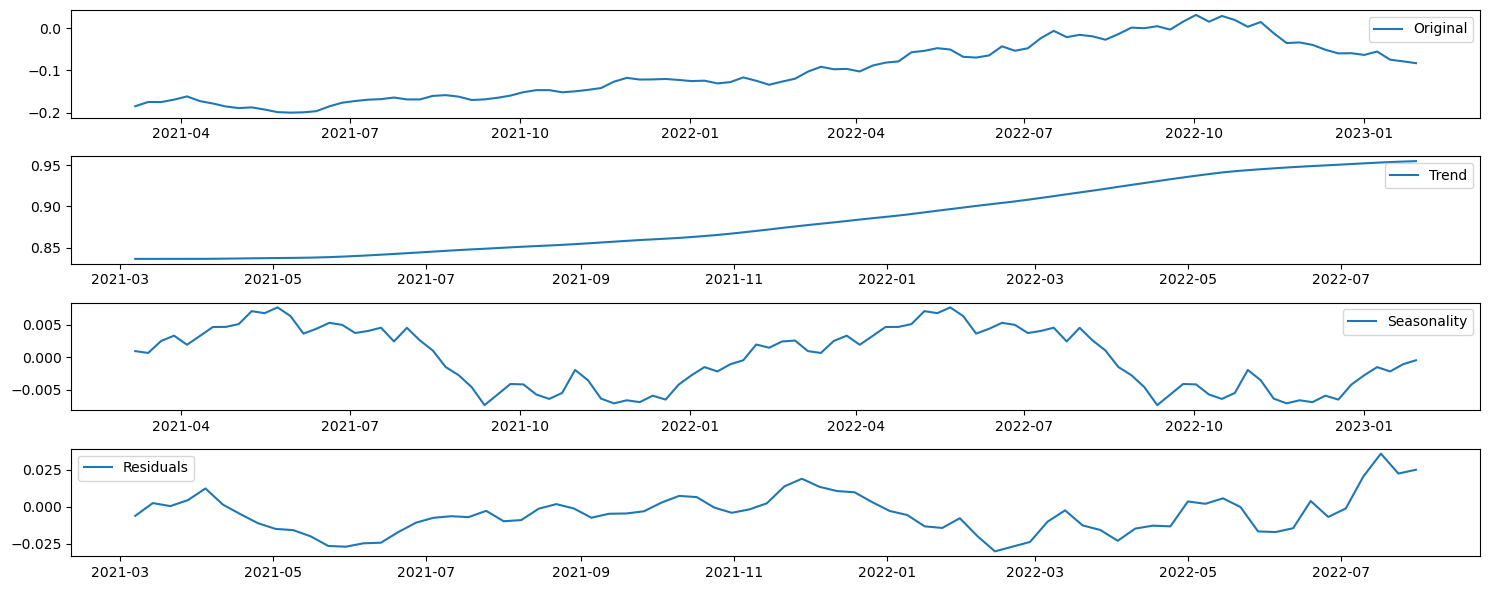

In [147]:
decomposition = seasonal_decompose(ts_euro_week)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Select the most recent weeks 
ts_euro_week_log_select = ts_euro_week_log[-100:]

plt.subplot(411)
plt.plot(ts_euro_week_log_select.index.to_pydatetime(), ts_euro_week_log_select.values, label='Original')
plt.legend(loc='best')
plt.subplot(412)
plt.plot(ts_euro_week_log_select.index.to_pydatetime(), trend[-100:].values, label='Trend')
plt.legend(loc='best')
plt.subplot(413)
plt.plot(ts_euro_week_log_select.index.to_pydatetime(), seasonal[-100:].values,label='Seasonality')
plt.legend(loc='best')
plt.subplot(414)
plt.plot(ts_euro_week_log_select.index.to_pydatetime(), residual[-100:].values, label='Residuals')
plt.legend(loc='best')
plt.tight_layout()

# Remova tendência e sazonalidade com diferenciação.

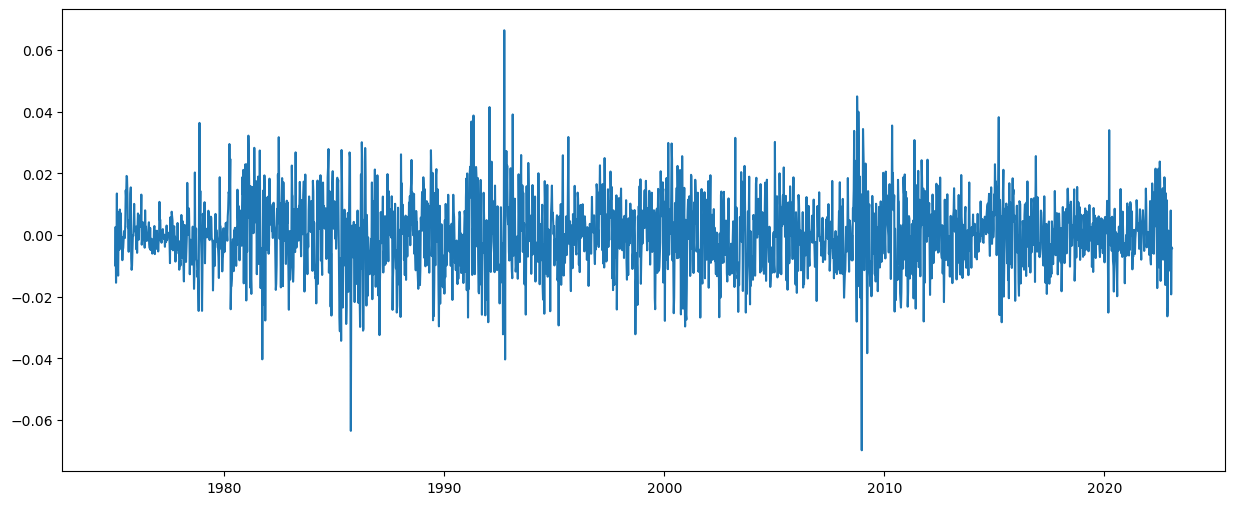

In [149]:
ts_euro_week_log_diff = ts_euro_week_log - ts_euro_week_log.shift()
plt.plot(ts_euro_week_log_diff.index.to_pydatetime(), ts_euro_week_log_diff.values)

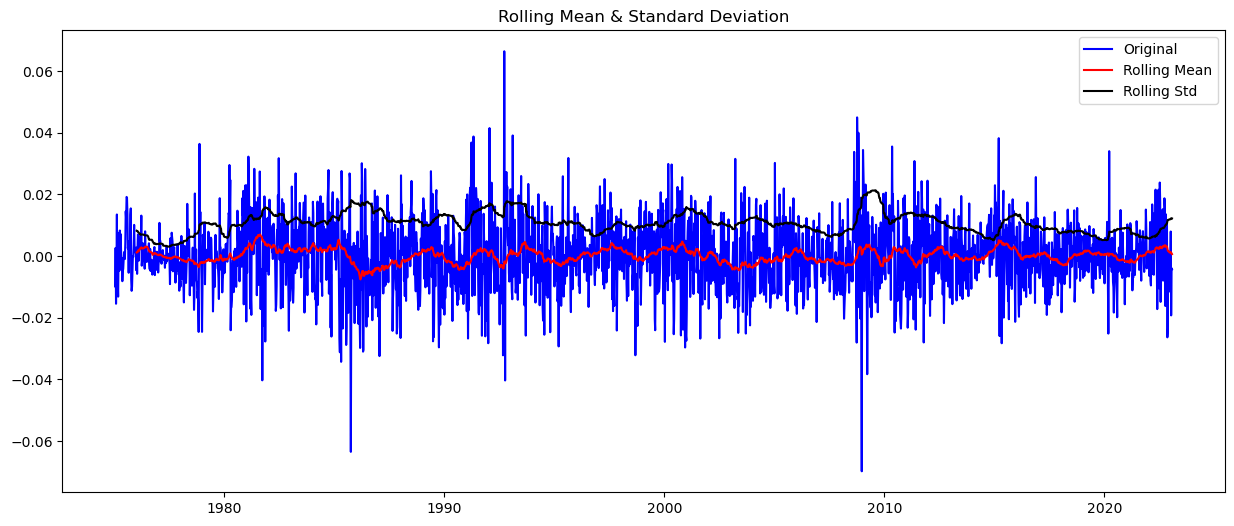

Results of Dickey-Fuller Test:
Test Statistic                  -25.965910
p-value                           0.000000
#Lags Used                        2.000000
Number of Observations Used    2505.000000
Critical Value (1%)              -3.432963
Critical Value (5%)              -2.862694
Critical Value (10%)             -2.567385
dtype: float64


In [150]:
ts_euro_week_log_diff.dropna(inplace=True)
check_stationarity(ts_euro_week_log_diff)

# Encontre parâmetros ideais e construa um modelo ARIMA.

### Plote a função de autocorrelação (ACF) e a função de autocorrelação parcial (PACF)

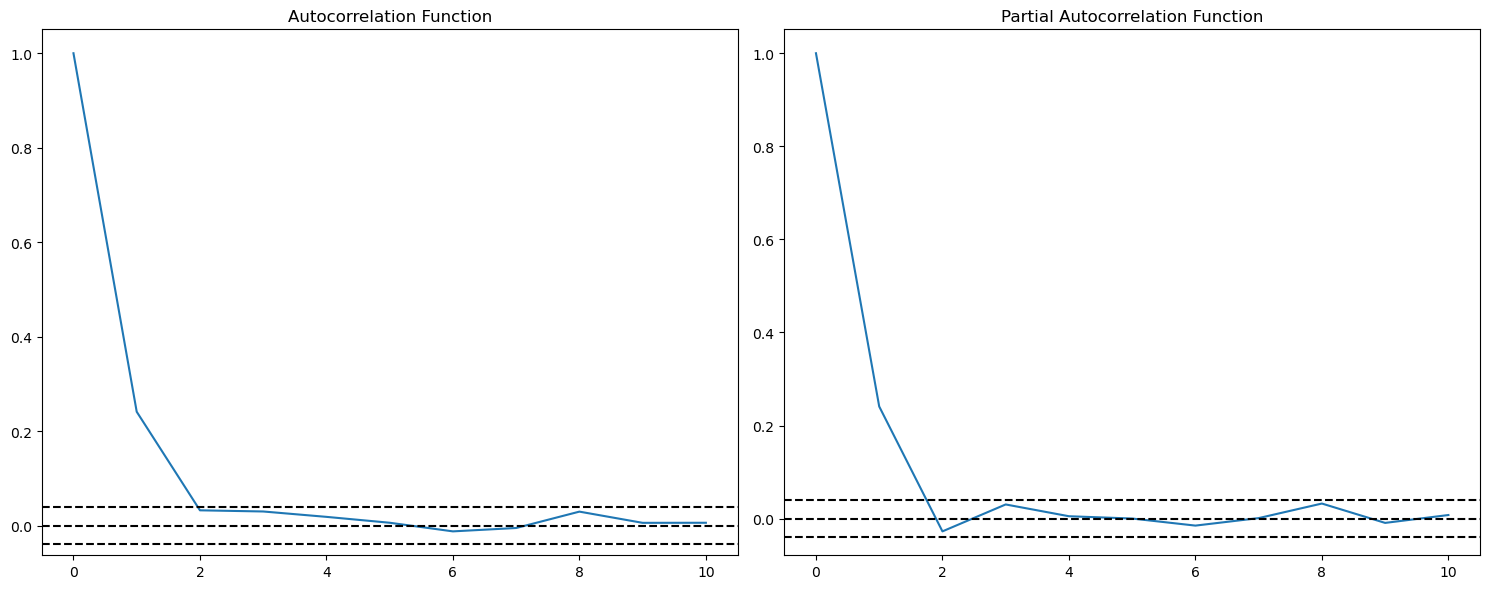

In [153]:
#ACF and PACF plots

lag_auto_corr = acf(ts_euro_week_log_diff, nlags=10)
lag_par_auto_corr = pacf(ts_euro_week_log_diff, nlags=10, method='ols')

#Plot ACF: 
plt.subplot(121) 
plt.plot(lag_auto_corr)
plt.axhline(y=0,linestyle='--',color='black')
plt.axhline(y=-1.96/np.sqrt(len(ts_euro_week_log_diff)),linestyle='--',color='black')
plt.axhline(y=1.96/np.sqrt(len(ts_euro_week_log_diff)),linestyle='--',color='black')
plt.title('Autocorrelation Function')

#Plot PACF:
plt.subplot(122)
plt.plot(lag_par_auto_corr)
plt.axhline(y=0,linestyle='--',color='black')
plt.axhline(y=-1.96/np.sqrt(len(ts_euro_week_log_diff)),linestyle='--',color='black')
plt.axhline(y=1.96/np.sqrt(len(ts_euro_week_log_diff)),linestyle='--',color='black')
plt.title('Partial Autocorrelation Function')

plt.tight_layout()

In [154]:
import warnings
warnings.filterwarnings('ignore')
import statsmodels.api as smapi
from statsmodels.tsa.arima.model import ARIMA
model = smapi.tsa.arima.ARIMA(ts_euro_week_log, order=(2, 1, 2))
results_ARIMA = model.fit()

In [155]:
# Tamanho do Dataframe:
print(f'Número de linhas: {len(ts_euro_week_log)}')
print(f'Número de colunas: {len(ts_euro_week_log)}\n')

# Identificando o tipo de cada variável:
display(ts_euro_week_log.dtypes)

Número de linhas: 2509
Número de colunas: 2509



dtype('float64')

In [156]:
# Tamanho do Dataframe:
print(f'Número de linhas: {len(results_ARIMA.fittedvalues)}')
print(f'Número de colunas: {len(results_ARIMA.fittedvalues)}\n')

# Identificando o tipo de cada variável:
display(results_ARIMA.fittedvalues.dtypes)

Número de linhas: 2509
Número de colunas: 2509



dtype('float64')

### Meça a variância entre os dados e os valores previstos pelo modelo.

                               SARIMAX Results                                
Dep. Variable:                  Value   No. Observations:                 2509
Model:                 ARIMA(2, 1, 2)   Log Likelihood                7767.422
Date:                Wed, 25 Jan 2023   AIC                         -15524.844
Time:                        14:07:55   BIC                         -15495.708
Sample:                    01-05-1975   HQIC                        -15514.268
                         - 01-29-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5022      0.514      0.978      0.328      -0.504       1.509
ar.L2          0.0483      0.100      0.485      0.627      -0.147       0.243
ma.L1         -0.2529      0.513     -0.493      0.6

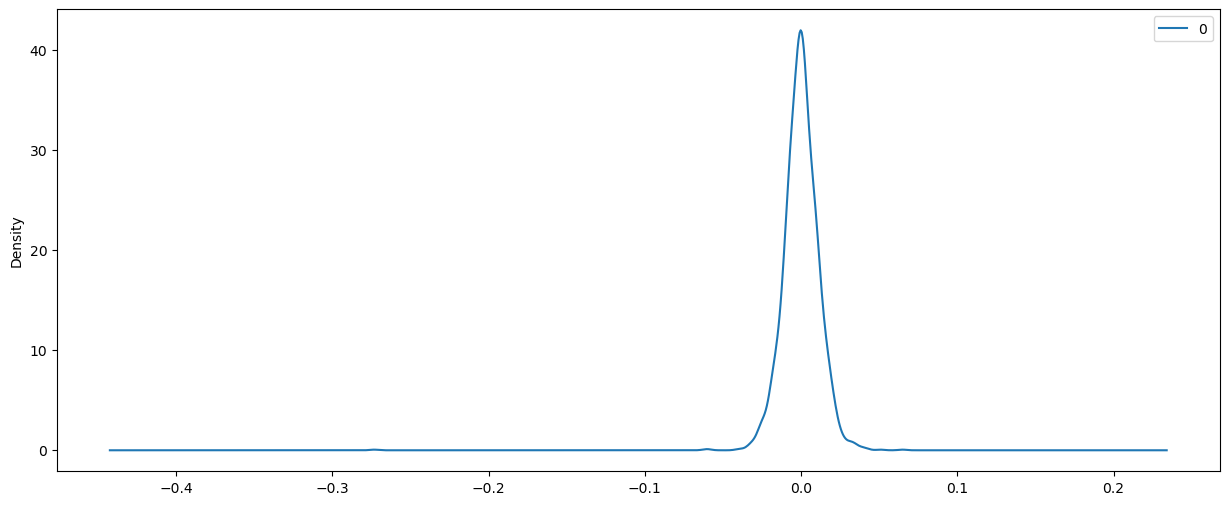

In [158]:
print(results_ARIMA.summary())
# plot residual errors
residuals = DataFrame(results_ARIMA.resid)
residuals.plot(kind='kde')
print(residuals.describe())

# Previsões de escala.

In [160]:
euro_predictions_ARIMA_diff = pd.Series(results_ARIMA.fittedvalues, copy=True)
print (euro_predictions_ARIMA_diff.head())

Date
1975-01-05    0.000000
1975-01-12   -0.273253
1975-01-19   -0.285457
1975-01-26   -0.279499
1975-02-02   -0.300098
Freq: W-SUN, dtype: float64


In [161]:
euro_predictions_ARIMA_diff_cumsum = euro_predictions_ARIMA_diff.cumsum()
euro_predictions_ARIMA_log = pd.Series(ts_euro_week_log.iloc[0], index=ts_euro_week_log.index)
euro_predictions_ARIMA_log = euro_predictions_ARIMA_log.add(euro_predictions_ARIMA_diff_cumsum,fill_value=0)

Text(0.5, 1.0, 'RMSE: 0.8783')

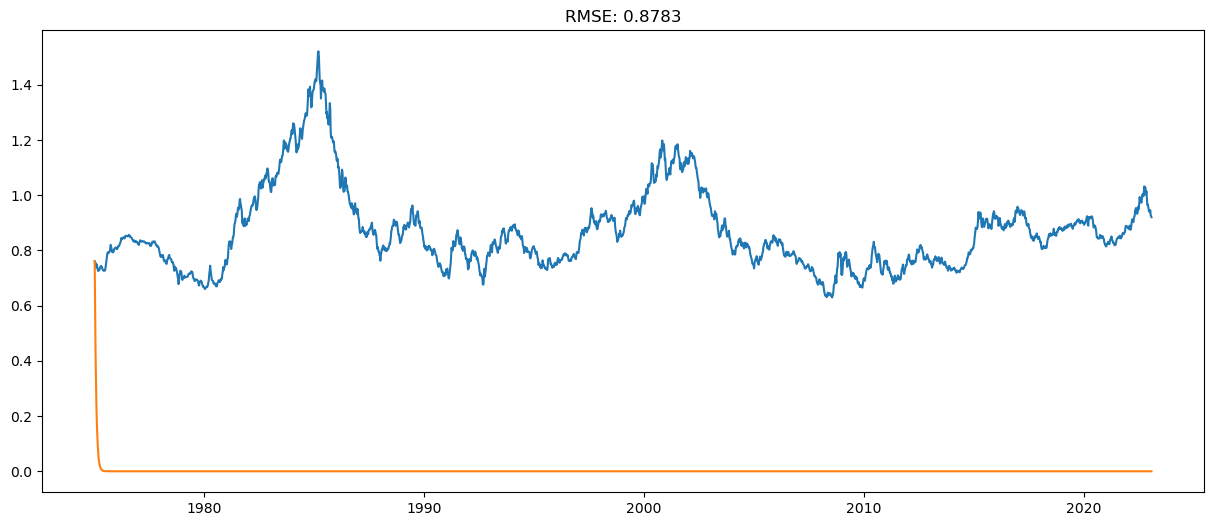

In [162]:
euro_predictions_ARIMA = np.exp(euro_predictions_ARIMA_log)
plt.plot(ts_euro_week.index.to_pydatetime(), ts_euro_week.values)
plt.plot(ts_euro_week.index.to_pydatetime(), euro_predictions_ARIMA.values)
plt.title('RMSE: %.4f'% np.sqrt(sum((euro_predictions_ARIMA-ts_euro_week)**2)/len(ts_euro_week)))

# Executar e visualizar previsões de séries temporais.

In [164]:
size = int(len(ts_euro_week_log) - 15)
train, test = ts_euro_week_log[0:size], ts_euro_week_log[size:len(ts_euro_week_log)]
historical = [x for x in train]
predictions = list()

print('Printing Predicted vs Expected Values...')
print('\n')
for t in range(len(test)):
    model = ARIMA(historical, order=(2,1,1))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(float(yhat))
    observed = test[t]
    historical.append(observed)
    print('Predicted Euro Rate = %f, Expected Euro Rate = %f' % (np.exp(yhat), np.exp(observed)))

error = mean_squared_error(test, predictions)

print('\n')
print('Printing Mean Squared Error of Predictions...')
print('Test MSE: %.6f' % error)

euro_predictions_series = pd.Series(predictions, index = test.index)

Printing Predicted vs Expected Values...


Predicted Euro Rate = 1.032142, Expected Euro Rate = 1.019480
Predicted Euro Rate = 1.017048, Expected Euro Rate = 1.003260
Predicted Euro Rate = 0.999532, Expected Euro Rate = 1.014640
Predicted Euro Rate = 1.017596, Expected Euro Rate = 0.988260
Predicted Euro Rate = 0.981414, Expected Euro Rate = 0.965400
Predicted Euro Rate = 0.960648, Expected Euro Rate = 0.966820
Predicted Euro Rate = 0.967810, Expected Euro Rate = 0.961240
Predicted Euro Rate = 0.959729, Expected Euro Rate = 0.950240
Predicted Euro Rate = 0.947710, Expected Euro Rate = 0.942060
Predicted Euro Rate = 0.940357, Expected Euro Rate = 0.942480
Predicted Euro Rate = 0.942810, Expected Euro Rate = 0.938667
Predicted Euro Rate = 0.937675, Expected Euro Rate = 0.946175
Predicted Euro Rate = 0.948189, Expected Euro Rate = 0.928160
Predicted Euro Rate = 0.923476, Expected Euro Rate = 0.924540
Predicted Euro Rate = 0.924243, Expected Euro Rate = 0.920600


Printing Mean Squared Err

### Você validou o modelo comparando suas previsões fora da amostra para as taxas do euro com os valores reais do conjunto de dados de teste e calculando o erro quadrático médio. 
### Agora plote as previsões de previsão contínua em relação aos valores observados. 
### Você verá que as previsões estão na escala correta e estão captando a tendência na série temporal original.

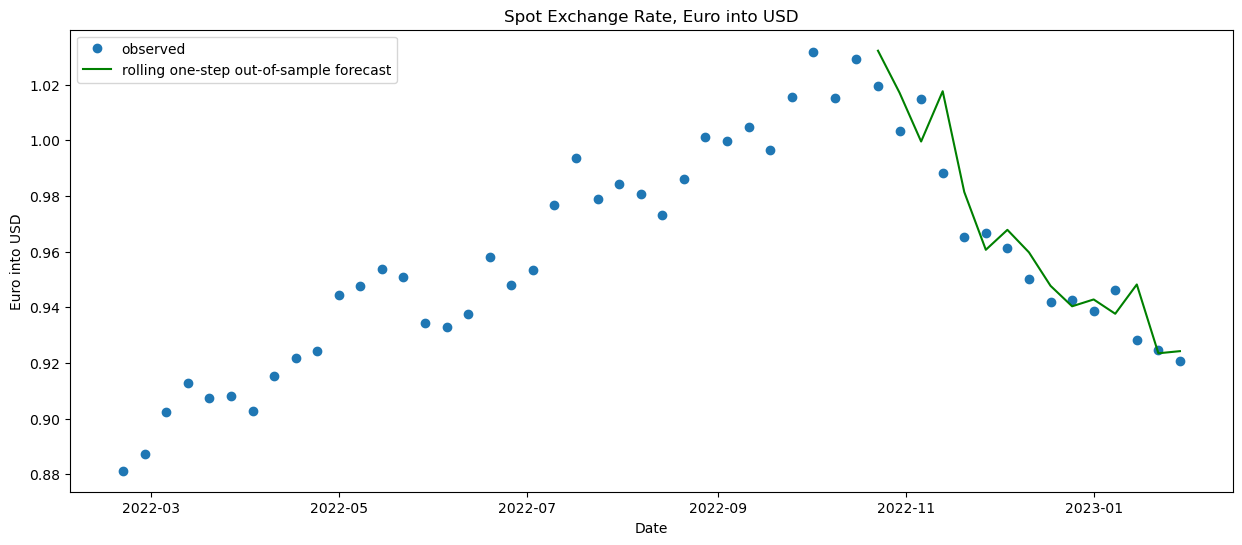

In [121]:
fig, ax = plt.subplots()
ax.set(title='Spot Exchange Rate, Euro into USD', xlabel='Date', ylabel='Euro into USD')
ax.plot(ts_euro_week[-50:], 'o', label='observed')
ax.plot(np.exp(euro_predictions_series), 'g', label='rolling one-step out-of-sample forecast')
legend = ax.legend(loc='upper left')
legend.get_frame().set_facecolor('w')

### Neste notebook Python, você aprendeu como carregar e visualizar uma série temporal, verificar a estacionaridade da série temporal e aplicar transformações à série temporal para torná-la estacionária. 
### Você aprendeu como encontrar os valores ideais para os parâmetros no modelo ARIMA e como usar o modelo para previsões dentro e fora da amostra.